# Bigram / Mini Transformer Language Model

Character-level language model trained on Tiny Shakespeare, built from a bigram baseline up to a small Transformer.

## 1. Setup

In [10]:
import math
import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Config

In [11]:
block_size = 32
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.1

batch_size = 32
learning_rate = 3e-4
max_iters = 10000
eval_interval = 500
eval_iters = 100
grad_clip = 1.0

checkpoint_path = "model.pt"

## 3. Load Data

In [12]:
with open("tiny shakespeare.txt", "r") as f:
    text = f.read()

## 4. Build the Character Vocabulary

In [13]:
vocab = sorted(list(set(text)))
vocab_size = len(vocab)

## 5. Encode / Decode

In [14]:
encod = {ch: i for i, ch in enumerate(vocab)}
decod = {i: ch for i, ch in enumerate(vocab)}

encode = lambda s: [encod[i] for i in s]
decode = lambda l: ''.join([decod[i] for i in l])

print(encode("hello world"))
decode(encode("hello world"))

[46, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]


'hello world'

## 6. Train / Test Split

In [15]:
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Data shape: {data.shape}")
if data.ndim > 1:
    data = data.flatten()
    print(f"Flattened data shape: {data.shape}")

n = int(0.9 * len(data))
train_set = data[:n]
test_set = data[n:]

(len(test_set) / (len(train_set) + len(test_set))) * 100

Data shape: torch.Size([1115394])


10.000053792650847

## 7. Batching

Samples a fresh random batch on every call instead of pre-materializing every window in memory.

In [16]:
def get_batch(split):
    source = train_set if split == "train" else test_set
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print(f"xb shape: {xb.shape}")
print(f"yb shape: {yb.shape}")

xb shape: torch.Size([32, 32])
yb shape: torch.Size([32, 32])


## 8. Transformer Building Blocks

In [17]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        tril = torch.tril(torch.ones(T, T)).to(x.device)
        wei = wei.masked_fill(tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, dropout):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, n_embd, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, n_embd, dropout)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## 9. Baseline: Bigram Language Model

In [18]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for i in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

bigram_model = BigramLanguageModel(vocab_size)
xb, yb = get_batch("train")
logits, loss = bigram_model(xb, yb)
print(f"Bigram Logits shape: {logits.shape}")
print(f"Bigram Loss: {loss}")

Bigram Logits shape: torch.Size([1024, 65])
Bigram Loss: 4.667929649353027


## 10. The Full Model — Small Transformer

In [19]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[Block(n_embd, n_head, dropout) for _ in range(n_layer)])

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for i in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = LanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)
xb, yb = get_batch("train")
logits, loss = model(xb, yb)
print(f"Logits shape: {logits.shape}")
print(f"Loss: {loss}")
print(f"Params: {sum(p.numel() for p in model.parameters()) / 1e3:.1f}K")

Logits shape: torch.Size([32, 32, 65])
Loss: 4.297855854034424
Params: 209.7K


## 11. Prediction Before Training

In [20]:
start_context = torch.zeros((1, 1), dtype=torch.long, device=device)

print("--- BEFORE TRAINING ---")
untrained_output = model.generate(start_context, max_new_tokens=300)[0].tolist()
print(decode(untrained_output))

--- BEFORE TRAINING ---

vpRHKf$ZBwXHCM:
bu?BlQaW ,b?AorUu
ieYXLMKMDMiCuEtlMNMBlj.Rlj;Xon
qk,d,qLeHQMMYd,MBNg inpMZ?-
klqQjl-'ngcnMN:at KWnevBqsalnL-n-DaMX PhFmRxBpXc
LaYT,MTtLaqiCuzRr?NuiDMLMDBsaaq,cfYtMFg'kL,xrmMwbkB'GqZUDwgTkkVg!GZTt3MpAMaheeh rZm:nS-clXaIKa,,yEu aLDc:ekuLfv,
mFe$HBLMiT;S
N-zOGFiMxp,E,NChmdZRnD OOR C;Z&n


## 12. Training Loop

Loss is averaged over `eval_iters` batches for a stable estimate. Gradient clipping and a cosine learning-rate schedule are applied every step.

In [21]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "test"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters)

train_losses = []
test_losses = []

for i in range(max_iters):
    if i % eval_interval == 0 or i == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        test_losses.append(losses["test"])
        print(f"Iteration {i}: Train Loss {losses['train']:.4f} | Test Loss {losses['test']:.4f}")

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    scheduler.step()

print(f"Final Loss: {loss.item():.4f}")

Iteration 0: Train Loss 4.3022 | Test Loss 4.3063
Iteration 500: Train Loss 2.4506 | Test Loss 2.4426
Iteration 1000: Train Loss 2.2753 | Test Loss 2.2832
Iteration 1500: Train Loss 2.1643 | Test Loss 2.1841
Iteration 2000: Train Loss 2.0753 | Test Loss 2.1136
Iteration 2500: Train Loss 2.0271 | Test Loss 2.0752
Iteration 3000: Train Loss 1.9805 | Test Loss 2.0338
Iteration 3500: Train Loss 1.9467 | Test Loss 2.0108
Iteration 4000: Train Loss 1.9173 | Test Loss 1.9869
Iteration 4500: Train Loss 1.8804 | Test Loss 1.9789
Iteration 5000: Train Loss 1.8749 | Test Loss 1.9583
Iteration 5500: Train Loss 1.8501 | Test Loss 1.9464
Iteration 6000: Train Loss 1.8397 | Test Loss 1.9357
Iteration 6500: Train Loss 1.8212 | Test Loss 1.9340
Iteration 7000: Train Loss 1.8291 | Test Loss 1.9176
Iteration 7500: Train Loss 1.8157 | Test Loss 1.9206
Iteration 8000: Train Loss 1.8174 | Test Loss 1.9097
Iteration 8500: Train Loss 1.8025 | Test Loss 1.9116
Iteration 9000: Train Loss 1.8069 | Test Loss 1.92

## 13. Plot Loss Curve

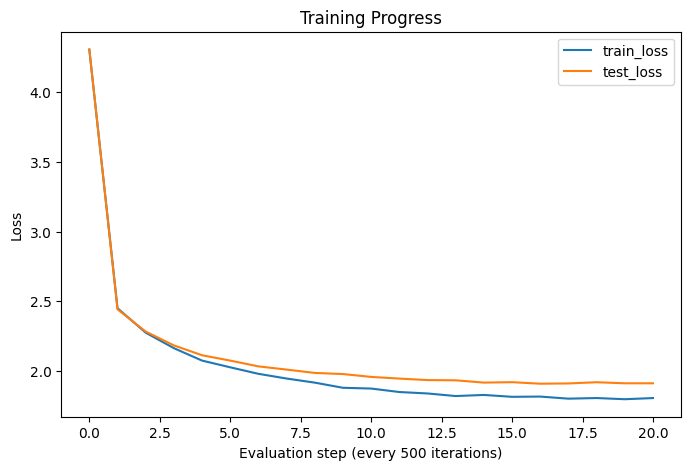

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train_loss")
plt.plot(test_losses, label="test_loss")
plt.xlabel(f"Evaluation step (every {eval_interval} iterations)")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()
plt.show()

## 14. Save & Reload Checkpoint

In [23]:
torch.save(model.state_dict(), checkpoint_path)
print(f"Saved checkpoint to {checkpoint_path}")

loaded_model = LanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)
loaded_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
loaded_model.eval()
print("Checkpoint loaded successfully")

Saved checkpoint to model.pt
Checkpoint loaded successfully


## 15. Prediction After Training

In [24]:
print("--- AFTER TRAINING ---")
trained_output = loaded_model.generate(start_context, max_new_tokens=1000)[0].tolist()
print(decode(trained_output))

--- AFTER TRAINING ---


DUKE:
If like's I be Royk, I praw land ardne to and to dear;
Oll, fet the an and Vo do my forchard trone
do a faim gord have is fair do com my thy, now can:
And of my under; his I hear: some a lothance
And thre bouthould conder wacke me; a net you have,
So this by say make man-goodlince,
Spalce his we a trient thee I on a sen,
To got answel wand thou groad, sorrest them a I
Hidn yould thinkne.

DUMES:
Where returtory, that It you preasach,
Oul Vere feart so, the leep of they froying.

ANTIO:
Good; so, minclown: hell cambner'dess
The disce my is am the duwst, and pothen the we ifle prath in for it may dises from
My of saince name, mane prite,' your us with hei
hance the diends to the eyourn toom: you son?
No contrewfet-heep imel. Teac your should maduchts: you his that then count's men,
After quundil, Ba inge cuitty. Hame, did and not the to roth's notheer
So hen nees hese: seese up rompon proy:
Eet row you alcench he togUpere; and my and As sunse him and tought